In [26]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

In [27]:
for file in os.listdir("/content"):
    if file.endswith(".csv.csv"):
        new_name = file.replace(".csv.csv", ".csv")
        os.rename(
            os.path.join("/content", file),
            os.path.join("/content", new_name)
        )
        print(file, "->", new_name)

In [28]:
files = {
    "Logistic Regression": "/content/comparison_predictions_logreg.csv",
    "AutoGluon L1": "/content/comparison_predictions_autogluon_l1.csv",
    "AutoGluon L2": "/content/comparison_predictions_autogluon_l2.csv",
    "AutoGluon L3": "/content/comparison_predictions_autogluon_l3.csv",
    "AutoGluon L4": "/content/comparison_predictions_autogluon_l4.csv",
    "H2O L1": "/content/comparison_predictions_h2o_l1.csv",
    "H2O L2": "/content/comparison_predictions_h2o_l2.csv",
    "H2O L3": "/content/comparison_predictions_h2o_l3.csv",
    "H2O L4": "/content/comparison_predictions_h2o_l4.csv",
}

data = {
    model: pd.read_csv(path)
    for model, path in files.items()
}

for model, df in data.items():
    print(model, df.shape)

OUT_DIR = "/content/pd_comparison_plots"
os.makedirs(OUT_DIR, exist_ok=True)

Logistic Regression (51070, 3)
AutoGluon L1 (51070, 3)
AutoGluon L2 (51070, 3)
AutoGluon L3 (51070, 3)
AutoGluon L4 (51070, 3)
H2O L1 (51070, 3)
H2O L2 (51070, 3)
H2O L3 (51070, 3)
H2O L4 (51070, 3)


# Helper Functions

In [ ]:
def get_prediction_column(df):
    if "pd_final" in df.columns:
        return "pd_final"
    elif "PD_final" in df.columns:
        return "PD_final"
    else:
        raise ValueError(f"No final PD column found. Columns are: {df.columns.tolist()}")

def get_target_column(df):
    if "y_true" in df.columns:
        return "y_true"
    elif "Default_Observed" in df.columns:
        return "Default_Observed"
    else:
        raise ValueError(f"No target column found. Columns are: {df.columns.tolist()}")

def plot_lorenz(ax, y_true, y_proba, label):
    df_plot = pd.DataFrame({
        "y_true": y_true,
        "y_proba": y_proba
    }).sort_values("y_proba", ascending=False)

    df_plot["cum_population"] = np.arange(1, len(df_plot) + 1) / len(df_plot)
    df_plot["cum_defaults"] = df_plot["y_true"].cumsum() / df_plot["y_true"].sum()

    auc = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1

    ax.plot(
        df_plot["cum_population"],
        df_plot["cum_defaults"],
        linewidth=0.8,
        label=f"{label} (Gini={gini:.3f})"
    )

def plot_calibration(ax, y_true, y_proba, label, n_bins=10):
    prob_true, prob_pred = calibration_curve(
        y_true,
        y_proba,
        n_bins=n_bins,
        strategy="quantile"
    )

    brier = brier_score_loss(y_true, y_proba)

    ax.plot(
        prob_pred,
        prob_true,
        marker="o",
        markersize=2.5,
        linewidth=0.8,
        label=f"{label} (Brier={brier:.3f})"
    )

def plot_model_group(model_names, title, filename):
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 14))

    for model_name in model_names:
        df = data[model_name]
        y_col = get_target_column(df)
        p_col = get_prediction_column(df)

        y_true = df[y_col].values
        y_proba = df[p_col].values


        plot_lorenz(axes[0], y_true, y_proba, model_name)
        plot_calibration(axes[1], y_true, y_proba, model_name)

    # Lorenz Curve 
    axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="gray", alpha=0.8, label="Random model")
    axes[0].set_title(f"{title}: Lorenz Curve", fontsize=15, pad=12, fontweight='bold')
    axes[0].set_xlabel("Cumulative share of borrowers", fontsize=12)
    axes[0].set_ylabel("Cumulative share of defaults", fontsize=12)
    axes[0].tick_params(labelsize=11)
    axes[0].grid(alpha=0.15)

    axes[0].legend(fontsize=14, loc='lower right')

    #cali curve
    axes[1].plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color='gray', label="Perfect calibration")
    axes[1].set_title(f"{title}: Calibration Curve", fontsize=15, pad=12, fontweight='bold')
    axes[1].set_xlabel("Mean predicted PD", fontsize=12)
    axes[1].set_ylabel("Observed default rate", fontsize=12)
    axes[1].tick_params(labelsize=11)
    axes[1].set_xlim(0, 0.7)
    axes[1].set_ylim(0, 0.7)
    axes[1].grid(alpha=0.15)

    axes[1].legend(fontsize=14, loc='upper left')

    plt.tight_layout(h_pad=3.5)

    save_path = os.path.join(OUT_DIR, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)





# Plots for comparison

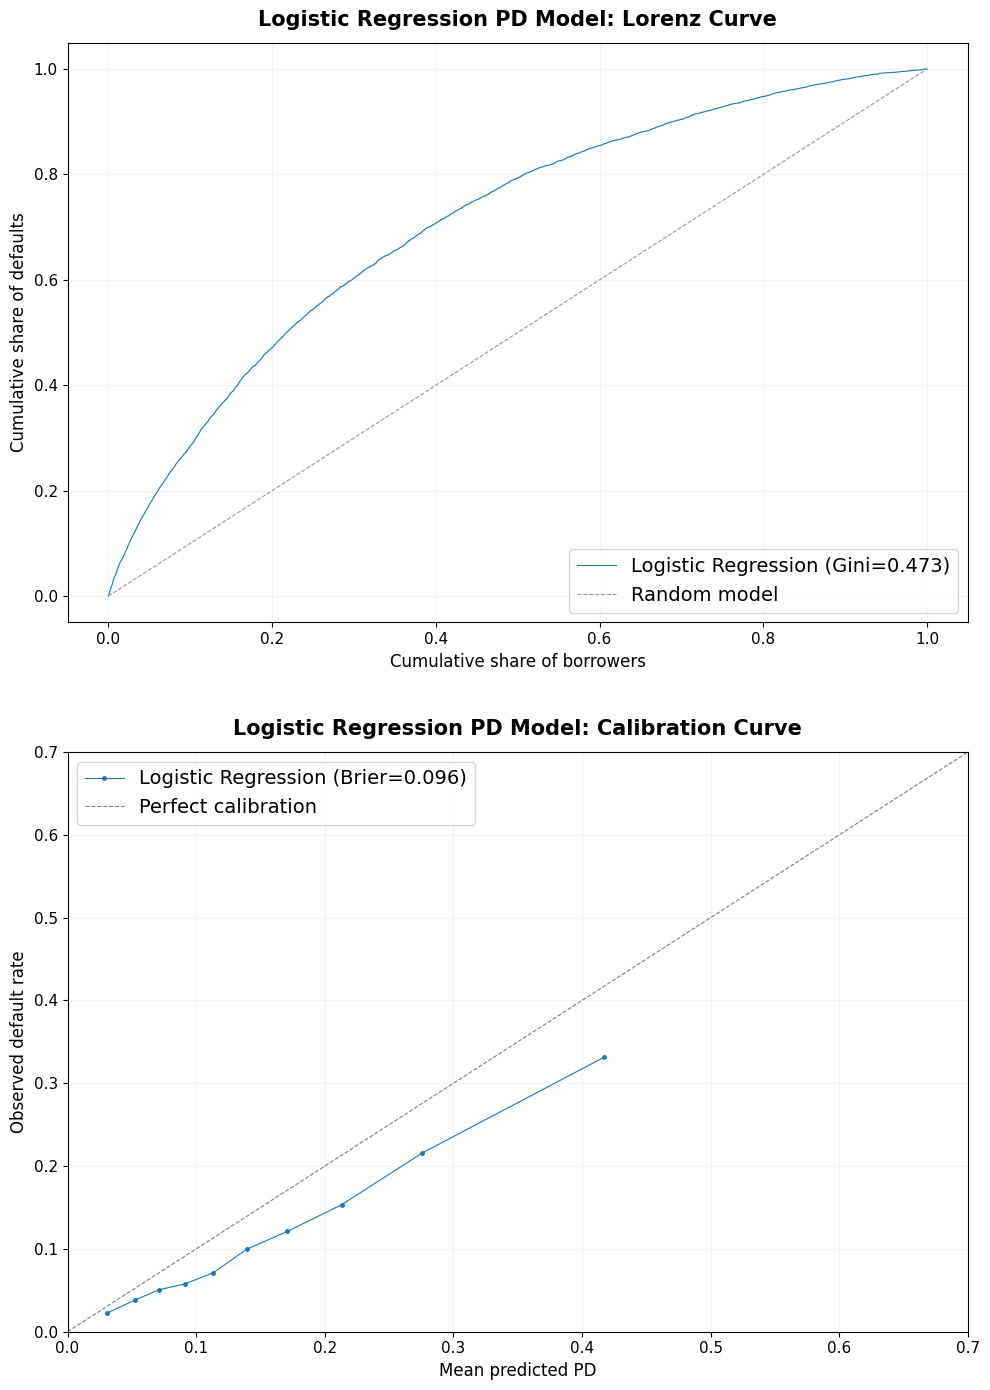

Saved: /content/pd_comparison_plots/pd_logreg_lorenz_calibration.png


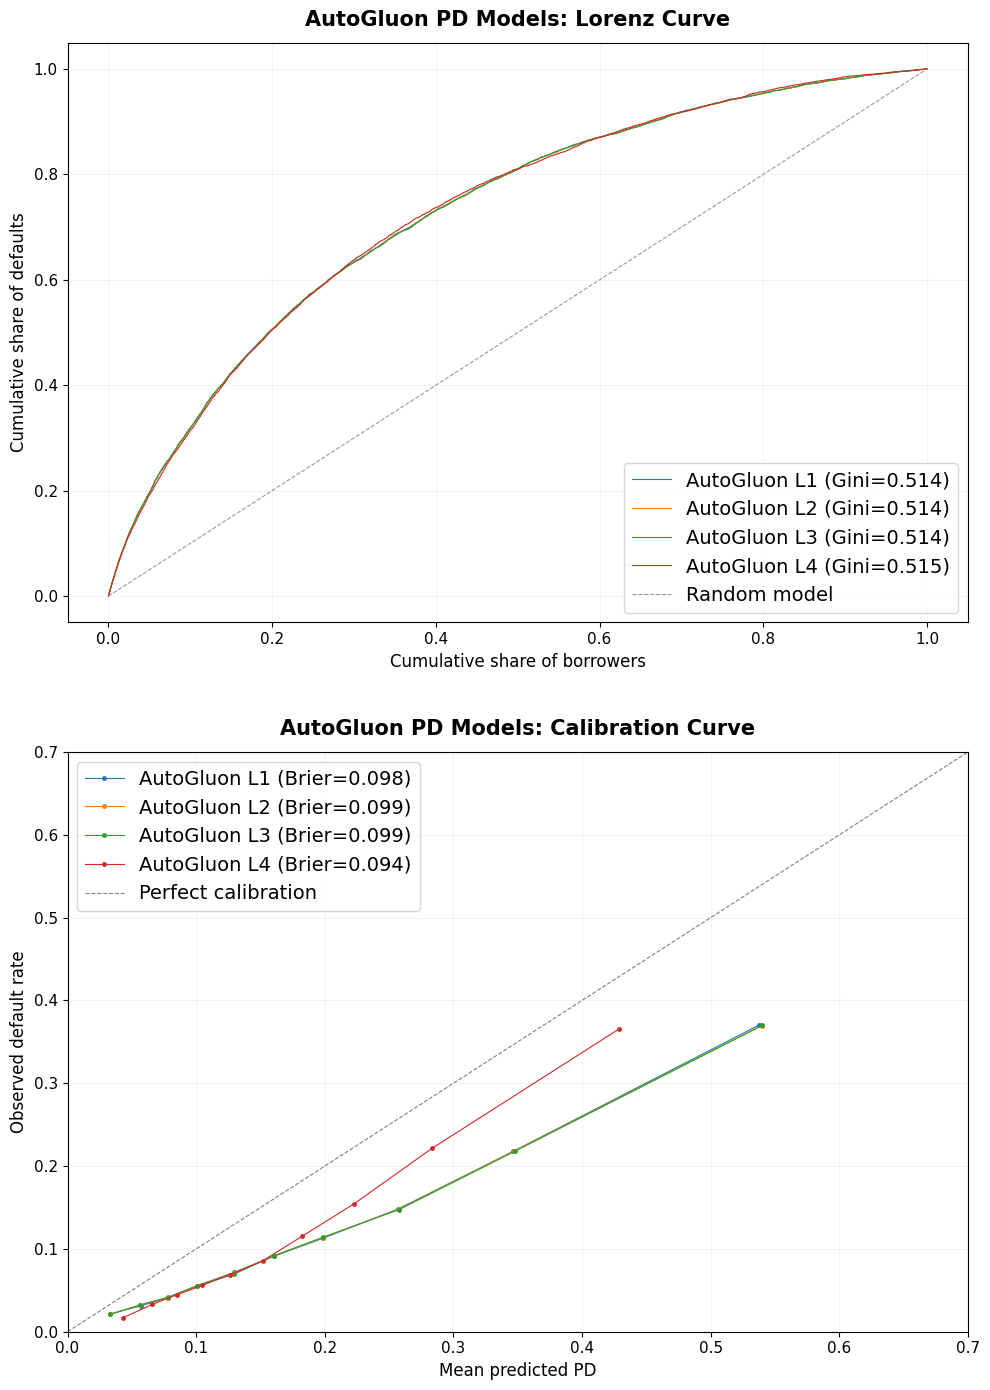

Saved: /content/pd_comparison_plots/pd_autogluon_lorenz_calibration.png


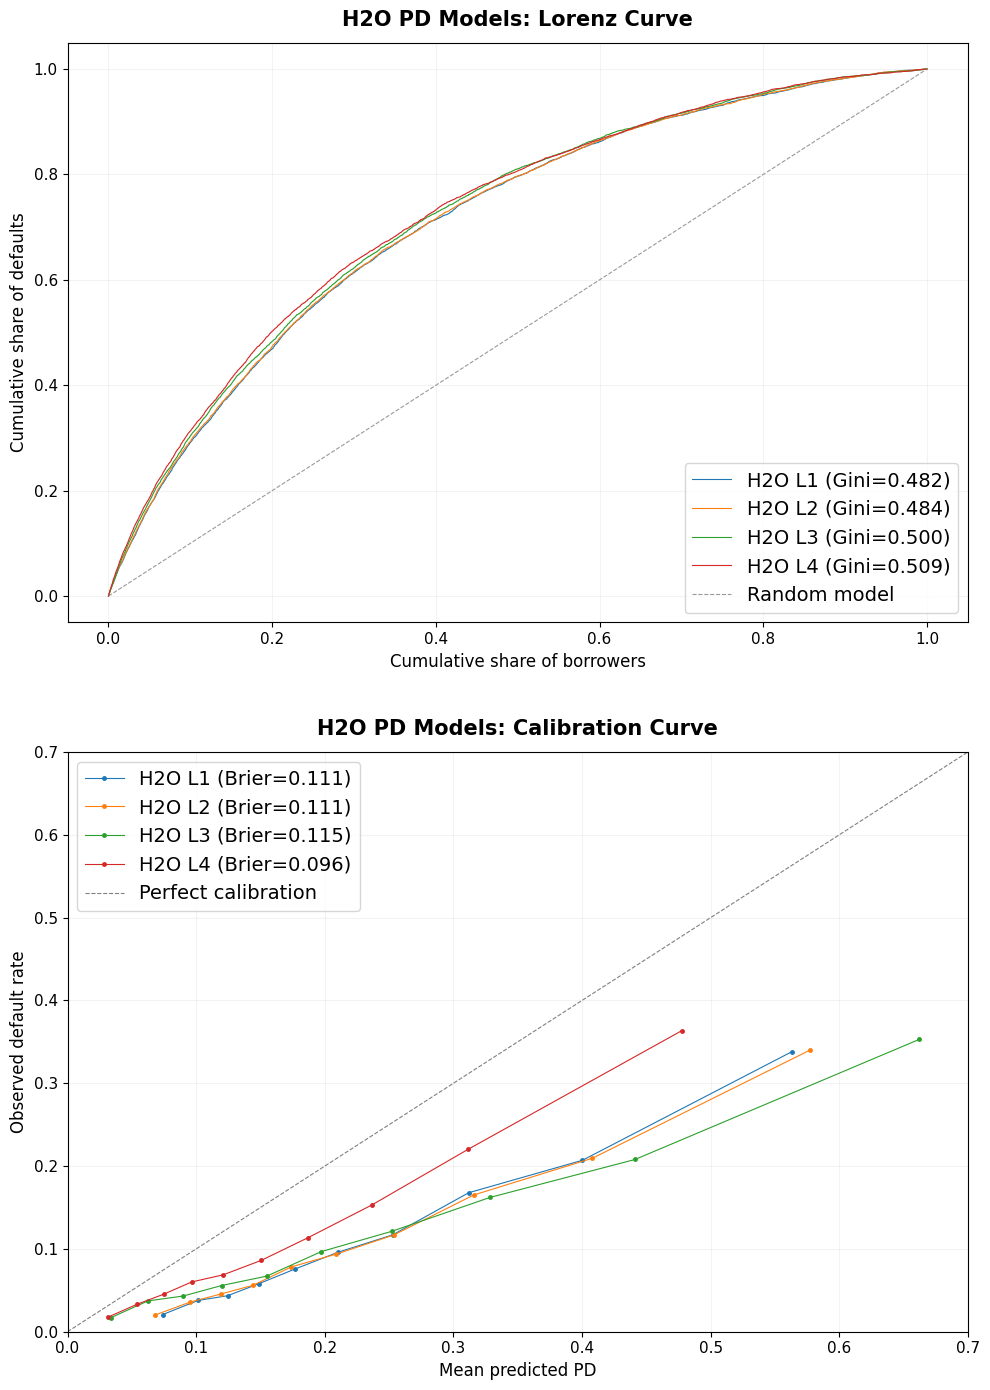

Saved: /content/pd_comparison_plots/pd_h2o_lorenz_calibration.png


In [30]:
# ------------------------------------------------------------
# 1. Logistic Regression
# ------------------------------------------------------------

plot_model_group(
    model_names=["Logistic Regression"],
    title="Logistic Regression PD Model",
    filename="pd_logreg_lorenz_calibration.png"
)

# ------------------------------------------------------------
# 2. AutoGluon Level 1-4
# ------------------------------------------------------------

plot_model_group(
    model_names=[
        "AutoGluon L1",
        "AutoGluon L2",
        "AutoGluon L3",
        "AutoGluon L4"
    ],
    title="AutoGluon PD Models",
    filename="pd_autogluon_lorenz_calibration.png"
)

# ------------------------------------------------------------
# 3. H2O Level 1-4
# ------------------------------------------------------------

plot_model_group(
    model_names=[
        "H2O L1",
        "H2O L2",
        "H2O L3",
        "H2O L4"
    ],
    title="H2O PD Models",
    filename="pd_h2o_lorenz_calibration.png"
)